# Output BAB 4.6 - Analisis Visual dan Spasial Hasil Segmentasi

Notebook ini menghasilkan panel visual input-label-prediksi, error map TP/FP/FN/TN, tabel aspek visual, dan narasi interpretatif untuk subbab 4.6.

## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran. Jika artefak belum tersedia, notebook membuat tabel status/warning dan tetap lanjut.


In [2]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [3]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.6 Analisis Visual dan Spasial Hasil Segmentasi

Tile representatif dipilih dari Aceh_Utara dengan syarat memiliki label banjir, prediksi U-Net, prediksi ProCANet, serta variasi TP/FP/FN yang cukup untuk dianalisis.

In [4]:
from matplotlib import patches
from matplotlib.colors import ListedColormap, BoundaryNorm

MODEL_KEYS = ['unet', 'procanet']
MODEL_LABELS = {'unet': 'U-Net', 'procanet': 'ProCANet'}


def prediction_path(model: str, tile_path: Path) -> Path:
    return RUNS / 'final' / model / 'eval_test' / 'predictions' / TEST_REGION / tile_path.name


def load_tile_and_predictions(tile_path: Path) -> dict:
    tile = load_npz(tile_path)
    x = np.asarray(tile['x'])
    y = np.asarray(tile['y']).squeeze().astype('uint8')
    valid = np.asarray(tile.get('valid_mask', np.ones_like(y)[None])).squeeze() > 0
    preds = {}
    probs = {}
    effective_valid = {}
    for model in MODEL_KEYS:
        p = prediction_path(model, tile_path)
        if not p.exists():
            preds[model] = None
            probs[model] = None
            effective_valid[model] = valid
            continue
        z = load_npz(p)
        pred = np.asarray(z['prediction']).squeeze().astype('uint8')
        prob = np.asarray(z.get('probability', pred)).squeeze().astype('float32')
        ev = np.asarray(z.get('effective_valid_mask', z.get('valid_mask', valid))).squeeze() > 0
        preds[model] = pred
        probs[model] = prob
        effective_valid[model] = ev
    return {'x': x, 'y': y, 'valid': valid, 'preds': preds, 'probs': probs, 'effective_valid': effective_valid}


def error_counts(y: np.ndarray, pred: np.ndarray, valid: np.ndarray) -> dict:
    mask = valid.astype(bool)
    return {
        'tn': int(((y == 0) & (pred == 0) & mask).sum()),
        'tp': int(((y == 1) & (pred == 1) & mask).sum()),
        'fp': int(((y == 0) & (pred == 1) & mask).sum()),
        'fn': int(((y == 1) & (pred == 0) & mask).sum()),
        'valid_pixels': int(mask.sum()),
        'label_positive_pixels': int(((y == 1) & mask).sum()),
        'predicted_positive_pixels': int(((pred == 1) & mask).sum()),
    }


def score_tile(counts_by_model: dict) -> float:
    label_pos = min(c['label_positive_pixels'] for c in counts_by_model.values())
    tp = sum(c['tp'] for c in counts_by_model.values())
    fp = sum(c['fp'] for c in counts_by_model.values())
    fn = sum(c['fn'] for c in counts_by_model.values())
    diversity = min(fp, fn) + 0.25 * max(fp, fn)
    return label_pos * 3 + tp + diversity

candidate_rows = []
tile_dir = DATASET / 'tiles' / '7ch' / 'by_region' / TEST_REGION
for tile_path in sorted(tile_dir.glob('*.npz')):
    if not all(prediction_path(model, tile_path).exists() for model in MODEL_KEYS):
        continue
    data = load_tile_and_predictions(tile_path)
    y = data['y']
    counts = {}
    usable = True
    for model in MODEL_KEYS:
        pred = data['preds'][model]
        if pred is None or pred.shape != y.shape:
            usable = False
            break
        valid = data['valid'] & data['effective_valid'][model]
        counts[model] = error_counts(y, pred, valid)
    if not usable:
        continue
    label_pos = min(c['label_positive_pixels'] for c in counts.values())
    if label_pos <= 0:
        continue
    row = {
        'tile': tile_path.name,
        'score': score_tile(counts),
        'label_positive_pixels': label_pos,
        'unet_tp': counts['unet']['tp'],
        'unet_fp': counts['unet']['fp'],
        'unet_fn': counts['unet']['fn'],
        'procanet_tp': counts['procanet']['tp'],
        'procanet_fp': counts['procanet']['fp'],
        'procanet_fn': counts['procanet']['fn'],
    }
    candidate_rows.append(row)

candidate_df = pd.DataFrame(candidate_rows).sort_values('score', ascending=False).reset_index(drop=True)
if candidate_df.empty:
    raise RuntimeError('Tidak ada tile Aceh_Utara dengan label banjir dan prediksi kedua model.')
selected_tile = tile_dir / candidate_df.iloc[0]['tile']
selected_summary = candidate_df.head(10).copy()
selected_summary.insert(0, 'rank', range(1, len(selected_summary) + 1))
save_table(selected_summary, '4_6_candidate_tile_selection.csv')
print(f'Selected tile: {selected_tile.relative_to(ROOT)}')


saved table: outputs/bab4/tables/4_6_candidate_tile_selection.csv (10 rows)


,rank,tile,score,label_positive_pixels,unet_tp,unet_fp,unet_fn,procanet_tp,procanet_fp,procanet_fn
0,1,Aceh_Utara_r001280_c005632.npz,1220186.50,247132,235920,392,11212,234926,1698,12206
1,2,Aceh_Utara_r001024_c005632.npz,1190398.25,242279,229704,970,12575,224633,699,17646
2,3,Aceh_Utara_r000512_c007168.npz,1176768.25,238818,231311,1379,7507,220180,908,18638
3,4,Aceh_Utara_r001536_c005632.npz,1120410.50,226433,217547,2234,8886,213153,2636,13280
4,5,Aceh_Utara_r001280_c005888.npz,1086861.75,223434,202998,2643,20436,196011,2943,27423
5,6,Aceh_Utara_r001536_c006400.npz,1082081.25,219020,208424,4560,10596,202739,2579,16281
6,7,Aceh_Utara_r001024_c005888.npz,1066885.75,221393,197841,1619,23552,188474,655,32919
7,8,Aceh_Utara_r001280_c005376.npz,1054085.50,214790,201902,2594,12888,195788,1459,19002
8,9,Aceh_Utara_r000512_c006912.npz,1051828.25,211501,205967,4285,5534,201322,1823,10179
9,10,Aceh_Utara_r000768_c007168.npz,1045673.25,210123,205856,3069,4267,201585,1593,8538


Selected tile: dataset/tiles/7ch/by_region/Aceh_Utara/Aceh_Utara_r001280_c005632.npz


saved table: outputs/bab4/tables/4_6_error_map_tile_counts.csv (2 rows)


,model,model_key,tile,valid_pixels,label_positive_pixels,predicted_positive_pixels,tn,tp,fp,fn,status
0,U-Net,unet,Aceh_Utara_r001280_c005632.npz,262144,247132,236312,14620,235920,392,11212,ok
1,ProCANet,procanet,Aceh_Utara_r001280_c005632.npz,262144,247132,236624,13314,234926,1698,12206,ok


saved figure: outputs/bab4/figures/4_6_segmentation_panel_aceh_utara.png


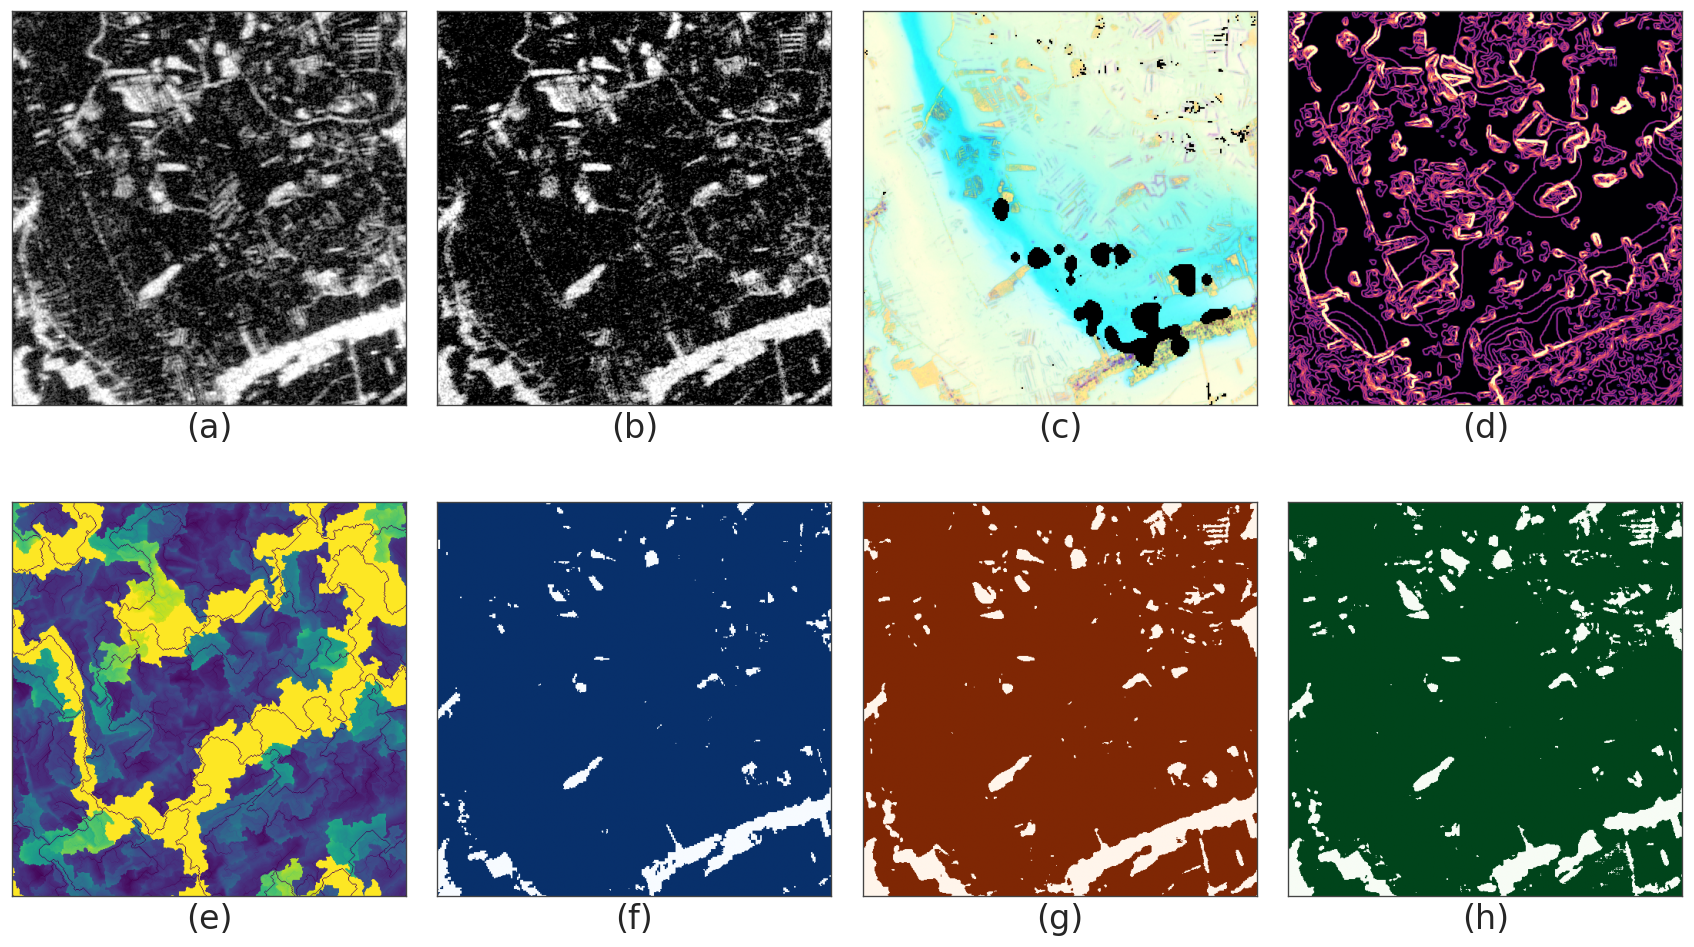

In [21]:
data = load_tile_and_predictions(selected_tile)

x = data["x"]
y = data["y"]
base_valid = data["valid"]
preds = data["preds"]
effective_valid = data["effective_valid"]


def add_panel_label(ax, label: str, y: float = -0.015, fontsize: int = 20):
    ax.text(
        0.5, y, label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=fontsize,
        clip_on=False
    )


panel_rows = []

for model in MODEL_KEYS:
    counts = error_counts(
        y,
        preds[model],
        base_valid & effective_valid[model]
    )

    counts.update({
        "model": MODEL_LABELS[model],
        "model_key": model,
        "tile": selected_tile.name,
        "status": "ok"
    })

    panel_rows.append(counts)

error_counts_df = pd.DataFrame(panel_rows)[[
    "model",
    "model_key",
    "tile",
    "valid_pixels",
    "label_positive_pixels",
    "predicted_positive_pixels",
    "tn",
    "tp",
    "fp",
    "fn",
    "status"
]]

save_table(error_counts_df, "4_6_error_map_tile_counts.csv")


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14.5, 8.8),
    constrained_layout=False
)

axes = axes.ravel()

valid_masked_label = np.ma.masked_where(~base_valid, y)

unet_mask = base_valid & effective_valid["unet"]
procanet_mask = base_valid & effective_valid["procanet"]

panels = [
    (normalize_image(x[0]), "gray"),
    (normalize_image(x[1]), "gray"),
    (
        np.dstack([
            normalize_image(x[4]),
            normalize_image(x[3]),
            normalize_image(x[2])
        ]),
        None
    ),
    (normalize_image(x[5]), "magma"),
    (normalize_image(x[6]), "viridis"),
    (valid_masked_label, "Blues"),
    (np.ma.masked_where(~unet_mask, preds["unet"]), "Oranges"),
    (np.ma.masked_where(~procanet_mask, preds["procanet"]), "Greens"),
]

subplot_labels = [
    "(a)", "(b)", "(c)", "(d)",
    "(e)", "(f)", "(g)", "(h)"
]

for idx, (ax, (arr, cmap)) in enumerate(zip(axes, panels)):
    if cmap:
        ax.imshow(arr, cmap=cmap)
    else:
        ax.imshow(arr)

    add_panel_label(
        ax,
        subplot_labels[idx],
        y=-0.015,
        fontsize=20
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#444444")

# Tidak memakai fig.suptitle.
# hspace diperkecil agar jarak antar baris subplot lebih rapat.
fig.subplots_adjust(
    top=0.98,
    bottom=0.05,
    left=0.02,
    right=0.98,
    hspace=0,
    wspace=0.08
)

panel_path = FIG_DIR / "4_6_segmentation_panel_aceh_utara.png"

fig.savefig(
    panel_path,
    bbox_inches="tight",
    dpi=300
)

print(f"saved figure: {panel_path.relative_to(ROOT)}")

plt.show()

saved figure: outputs/bab4/figures/4_6_error_map_aceh_utara.png


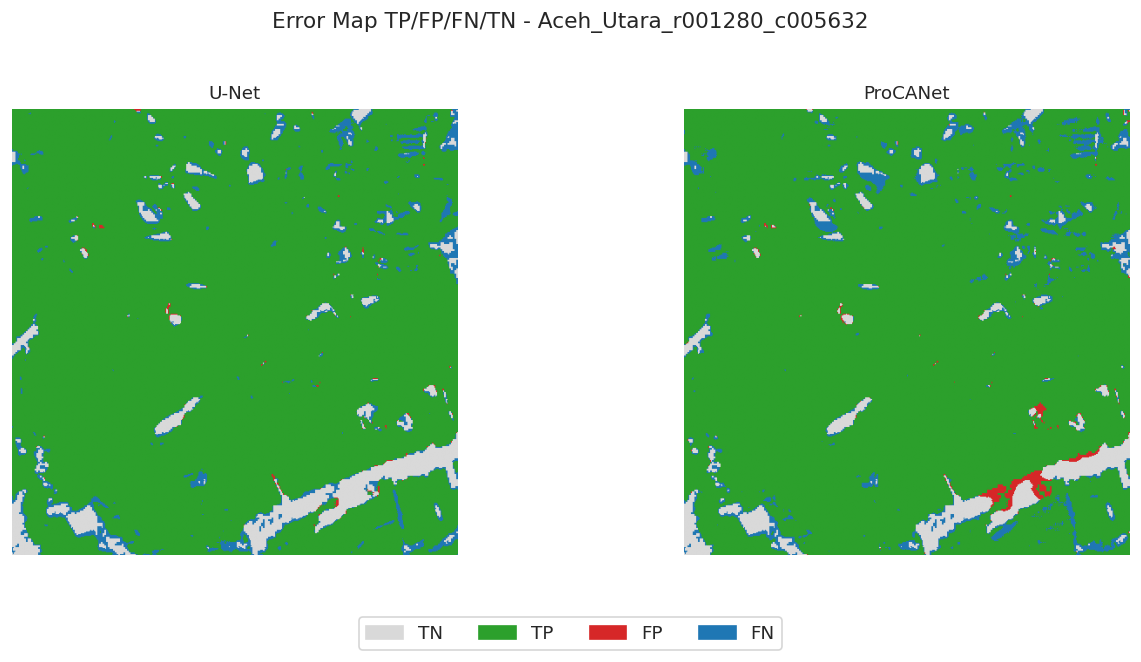

In [6]:
def error_map_array(y: np.ndarray, pred: np.ndarray, valid: np.ndarray) -> np.ndarray:
    err = np.full(y.shape, -1, dtype='int16')
    mask = valid.astype(bool)
    err[(y == 0) & (pred == 0) & mask] = 0  # TN
    err[(y == 1) & (pred == 1) & mask] = 1  # TP
    err[(y == 0) & (pred == 1) & mask] = 2  # FP
    err[(y == 1) & (pred == 0) & mask] = 3  # FN
    return err

err_cmap = ListedColormap(['#D9D9D9', '#2CA02C', '#D62728', '#1F77B4'])
err_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], err_cmap.N)
legend_items = [
    patches.Patch(color='#D9D9D9', label='TN'),
    patches.Patch(color='#2CA02C', label='TP'),
    patches.Patch(color='#D62728', label='FP'),
    patches.Patch(color='#1F77B4', label='FN'),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.8), constrained_layout=False)
for ax, model in zip(axes, MODEL_KEYS):
    valid = base_valid & effective_valid[model]
    err = error_map_array(y, preds[model], valid)
    masked = np.ma.masked_where(err < 0, err)
    ax.imshow(masked, cmap=err_cmap, norm=err_norm)
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.axis('off')
fig.legend(handles=legend_items, loc='lower center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.03))
fig.suptitle(f'Error Map TP/FP/FN/TN - {selected_tile.stem}', fontsize=13, y=0.96)
fig.subplots_adjust(top=0.82, bottom=0.18, left=0.03, right=0.97, wspace=0.18)
error_path = FIG_DIR / '4_6_error_map_aceh_utara.png'
fig.savefig(error_path, bbox_inches='tight', dpi=300)
print(f'saved figure: {error_path.relative_to(ROOT)}')
plt.show()


In [7]:
counts = error_counts_df.set_index('model')
u = counts.loc['U-Net']
p = counts.loc['ProCANet']
visual_aspects = pd.DataFrame([
    {
        'aspek_visual': 'Cakupan prediksi banjir',
        'U-Net': f"{int(u['predicted_positive_pixels']):,} piksel pada tile",
        'ProCANet': f"{int(p['predicted_positive_pixels']):,} piksel pada tile",
        'interpretasi': 'Cakupan lebih besar biasanya menaikkan recall tetapi dapat menambah FP.',
    },
    {
        'aspek_visual': 'Area benar terdeteksi (TP)',
        'U-Net': f"{int(u['tp']):,} piksel TP",
        'ProCANet': f"{int(p['tp']):,} piksel TP",
        'interpretasi': 'TP menunjukkan bagian label banjir yang tertangkap oleh prediksi.',
    },
    {
        'aspek_visual': 'False positive',
        'U-Net': f"{int(u['fp']):,} piksel FP",
        'ProCANet': f"{int(p['fp']):,} piksel FP",
        'interpretasi': 'FP dapat muncul pada permukaan berbackscatter rendah, tanah basah, radar shadow, atau badan air permanen.',
    },
    {
        'aspek_visual': 'False negative',
        'U-Net': f"{int(u['fn']):,} piksel FN",
        'ProCANet': f"{int(p['fn']):,} piksel FN",
        'interpretasi': 'FN menunjukkan banjir UNOSAT yang tidak tertangkap, terutama jika tipis atau kontras sensor lemah.',
    },
    {
        'aspek_visual': 'Kecenderungan relatif',
        'U-Net': 'lebih luas' if u['predicted_positive_pixels'] > p['predicted_positive_pixels'] else 'lebih selektif',
        'ProCANet': 'lebih luas' if p['predicted_positive_pixels'] > u['predicted_positive_pixels'] else 'lebih selektif',
        'interpretasi': 'Kecenderungan tile dibaca bersama metrik final 4.5 agar tidak overclaim dari satu contoh visual.',
    },
])
save_table(visual_aspects, '4_6_visual_model_aspects.csv')


saved table: outputs/bab4/tables/4_6_visual_model_aspects.csv (5 rows)


,aspek_visual,U-Net,ProCANet,interpretasi
0,Cakupan prediksi banjir,"236,312 piksel pada tile","236,624 piksel pada tile",Cakupan lebih besar biasanya menaikkan recall ...
1,Area benar terdeteksi (TP),"235,920 piksel TP","234,926 piksel TP",TP menunjukkan bagian label banjir yang tertan...
2,False positive,392 piksel FP,"1,698 piksel FP",FP dapat muncul pada permukaan berbackscatter ...
3,False negative,"11,212 piksel FN","12,206 piksel FN",FN menunjukkan banjir UNOSAT yang tidak tertan...
4,Kecenderungan relatif,lebih selektif,lebih luas,Kecenderungan tile dibaca bersama metrik final...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_6_visual_model_aspects.csv')

In [8]:
u = error_counts_df.set_index('model').loc['U-Net']
p = error_counts_df.set_index('model').loc['ProCANet']
metrics_path = TABLE_DIR / '4_5_final_metrics.csv'
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path).set_index('model')
    u_iou, p_iou = metrics.loc['U-Net', 'iou'], metrics.loc['ProCANet', 'iou']
    u_recall, p_recall = metrics.loc['U-Net', 'recall'], metrics.loc['ProCANet', 'recall']
    u_precision, p_precision = metrics.loc['U-Net', 'precision'], metrics.loc['ProCANet', 'precision']
else:
    u_iou = p_iou = u_recall = p_recall = u_precision = p_precision = float('nan')

lines = [
    '# Interpretasi Visual dan Spasial 4.6',
    '',
    f"Panel visual menggunakan tile `{selected_tile.name}` dari Aceh_Utara karena tile ini memiliki label banjir dan prediksi dari kedua model. Area benar ditunjukkan oleh piksel TP pada error map: U-Net menangkap {int(u['tp']):,} piksel TP, sedangkan ProCANet menangkap {int(p['tp']):,} piksel TP pada tile yang sama.",
    '',
    f"False positive menunjukkan piksel non-banjir yang diprediksi banjir. Pada tile ini U-Net memiliki {int(u['fp']):,} piksel FP dan ProCANet memiliki {int(p['fp']):,} piksel FP. Area seperti ini perlu ditafsirkan hati-hati karena permukaan berbackscatter rendah, tanah basah, radar shadow, atau badan air permanen dapat terlihat mirip dengan genangan banjir pada citra SAR.",
    '',
    f"False negative menunjukkan piksel banjir UNOSAT yang tidak tertangkap model. Pada tile ini U-Net memiliki {int(u['fn']):,} piksel FN dan ProCANet memiliki {int(p['fn']):,} piksel FN. FN dapat muncul pada genangan tipis, batas label yang tidak presisi, atau area dengan kontras sensor yang lemah sehingga sinyal banjir tidak cukup tegas.",
    '',
    f"Perbandingan visual perlu dibaca bersama metrik kuantitatif 4.5. Pada tile contoh ini, ProCANet sedikit lebih luas dari U-Net, tetapi evaluasi final menunjukkan U-Net memiliki IoU {u_iou:.4f} dan recall {u_recall:.4f}, sedangkan ProCANet memiliki precision {p_precision:.4f}. Karena itu, panel visual tidak menjadi bukti tunggal, melainkan contoh spasial untuk menjelaskan trade-off lokal: perubahan kecil pada cakupan prediksi dapat menggeser FP dan FN, sementara kesimpulan model tetap harus merujuk metrik agregat.",
]
path = NARRATIVE_DIR / '4_6_visual_spatial_interpretation.md'
path.write_text('\n'.join(lines) + '\n')
print(f'saved narrative: {path.relative_to(ROOT)}')
print('\n'.join(lines))


saved narrative: outputs/bab4/narratives/4_6_visual_spatial_interpretation.md
# Interpretasi Visual dan Spasial 4.6

Panel visual menggunakan tile `Aceh_Utara_r001280_c005632.npz` dari Aceh_Utara karena tile ini memiliki label banjir dan prediksi dari kedua model. Area benar ditunjukkan oleh piksel TP pada error map: U-Net menangkap 235,920 piksel TP, sedangkan ProCANet menangkap 234,926 piksel TP pada tile yang sama.

False positive menunjukkan piksel non-banjir yang diprediksi banjir. Pada tile ini U-Net memiliki 392 piksel FP dan ProCANet memiliki 1,698 piksel FP. Area seperti ini perlu ditafsirkan hati-hati karena permukaan berbackscatter rendah, tanah basah, radar shadow, atau badan air permanen dapat terlihat mirip dengan genangan banjir pada citra SAR.

False negative menunjukkan piksel banjir UNOSAT yang tidak tertangkap model. Pada tile ini U-Net memiliki 11,212 piksel FN dan ProCANet memiliki 12,206 piksel FN. FN dapat muncul pada genangan tipis, batas label yang tidak presis

In [9]:
expected = [
    ('wajib', 'Panel visual input-label-prediksi', FIG_DIR / '4_6_segmentation_panel_aceh_utara.png'),
    ('sangat_disarankan', 'Error map TP/FP/FN/TN', FIG_DIR / '4_6_error_map_aceh_utara.png'),
    ('wajib', 'Tabel jumlah TP/FP/FN/TN pada tile', TABLE_DIR / '4_6_error_map_tile_counts.csv'),
    ('opsional', 'Tabel aspek visual model', TABLE_DIR / '4_6_visual_model_aspects.csv'),
    ('disarankan', 'Tabel pemilihan tile representatif', TABLE_DIR / '4_6_candidate_tile_selection.csv'),
    ('narasi_wajib', 'Interpretasi area benar', NARRATIVE_DIR / '4_6_visual_spatial_interpretation.md'),
    ('narasi_wajib', 'Interpretasi false positive', NARRATIVE_DIR / '4_6_visual_spatial_interpretation.md'),
    ('narasi_wajib', 'Interpretasi false negative', NARRATIVE_DIR / '4_6_visual_spatial_interpretation.md'),
    ('narasi_wajib', 'Pengait visual-kuantitatif', NARRATIVE_DIR / '4_6_visual_spatial_interpretation.md'),
]
coverage = pd.DataFrame([
    {
        'priority': priority,
        'todo_item': item,
        'artifact': str(path.relative_to(ROOT)),
        'exists': path.exists(),
        'size_bytes': path.stat().st_size if path.exists() else 0,
    }
    for priority, item, path in expected
])
save_table(coverage, '4_6_todo_coverage_checklist.csv')
missing = coverage[~coverage['exists']]
if missing.empty:
    print('All 4.6 checklist artifacts are available.')
else:
    display(missing)


saved table: outputs/bab4/tables/4_6_todo_coverage_checklist.csv (9 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Panel visual input-label-prediksi,outputs/bab4/figures/4_6_segmentation_panel_ac...,True,6885024
1,sangat_disarankan,Error map TP/FP/FN/TN,outputs/bab4/figures/4_6_error_map_aceh_utara.png,True,694780
2,wajib,Tabel jumlah TP/FP/FN/TN pada tile,outputs/bab4/tables/4_6_error_map_tile_counts.csv,True,287
3,opsional,Tabel aspek visual model,outputs/bab4/tables/4_6_visual_model_aspects.csv,True,778
4,disarankan,Tabel pemilihan tile representatif,outputs/bab4/tables/4_6_candidate_tile_selecti...,True,956
5,narasi_wajib,Interpretasi area benar,outputs/bab4/narratives/4_6_visual_spatial_int...,True,1505
6,narasi_wajib,Interpretasi false positive,outputs/bab4/narratives/4_6_visual_spatial_int...,True,1505
7,narasi_wajib,Interpretasi false negative,outputs/bab4/narratives/4_6_visual_spatial_int...,True,1505
8,narasi_wajib,Pengait visual-kuantitatif,outputs/bab4/narratives/4_6_visual_spatial_int...,True,1505


All 4.6 checklist artifacts are available.
